# Objective 3 — Skill Gap Analysis

Extracts skills from resume, matches against JobStreet dataset using Hybrid model (0.7 TF-IDF + 0.3 SBERT), then computes skill gap for top 10 matched jobs.

## Install Packages

In [4]:
# Run once
!pip -q install pandas numpy scikit-learn pdfplumber sentence-transformers matplotlib seaborn python-dateutil

## Import Libraries

In [6]:
import os, re, ast, json, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from scipy.sparse import save_npz, load_npz
import pdfplumber
from collections import Counter
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## Helper Functions

In [8]:
# Section headers 
STOP_HEADERS = [
    'work experience', 'experience', 'employment', 'professional experience',
    'career history', 'work history', 'education', 'academic', 'qualifications',
    'academic background', 'projects', 'academic projects', 'personal projects',
    'certifications', 'certification', 'licenses', 'awards', 'languages',
    'interests', 'hobbies', 'references', 'volunteer', 'achievements',
    'publications', 'extracurricular'
]

SKILLS_HEADERS = [
    'skills', 'skills summary', 'technical skills', 'key skills',
    'competencies', 'tools', 'technologies', 'core competencies',
    'skill set', 'technical expertise', 'my toolkit', 'toolkit',
    'tech stack', 'areas of expertise', 'professional skills', 'it skills',
    'software skills', 'programming skills', 'programming languages',
    'languages & tools', 'languages and tools', 'tools & technologies',
    'tools and technologies', 'technical proficiencies', 'proficiencies',
    'capabilities', 'technical summary', 'relevant skills',
    'hard skills', 'soft skills', 'key competencies'
]

GENERIC_PHRASES = {
    'documentation', 'problem solving', 'communication', 'teamwork',
    'collaboration', 'ability', 'skills', 'expertise', 'experience',
    'knowledge', 'understanding', 'developing', 'develop', 'including',
    'sector', 'service', 'services', 'models', 'model', 'foundation',
    'foundations', 'required', 'related', 'grant', 'education', 'research',
    'scientists', 'cutting', 'edge', 'solutions', 'scientific', 'performance',
    'safety', 'quality', 'metrics', 'production', 'technical', 'architecture',
    'web', 'applications', 'summary', 'objective', 'profile', 'history',
    'career', 'professional'
}

# PDF reader (handles single and two-column layouts) 
def read_pdf(path):
    standard_pages = []
    column_pages = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            std = page.extract_text() or ''
            standard_pages.append(std)
            x0, top, x1, bottom = page.bbox
            w = x1 - x0
            mid = x0 + w * 0.50
            try:
                left  = page.crop((x0, top, mid + w * 0.02, bottom))
                right = page.crop((mid - w * 0.02, top, x1, bottom))
                col   = (left.extract_text() or '') + '\n' + (right.extract_text() or '')
            except Exception:
                col = std
            column_pages.append(col)
    std_full = _clean("|".join(standard_pages))
    col_full = _clean('\n'.join(column_pages))
    lines = [l for l in std_full.split('\n') if l.strip()]
    long_ratio = sum(1 for l in lines if len(l) > 120) / max(len(lines), 1)
    return col_full if long_ratio > 0.3 else std_full

def _clean(t):
    t = str(t).replace('\r', '\n')
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n{2,}', '\n', t)
    t = re.sub(r'\(cid:\d+\)', ' ', t)
    t = re.sub(r'cid:\d+', ' ', t)
    return t.strip()

def clean_text(t):
    return _clean(t)

# Section detection 
def normalize_line(s):
    return re.sub(r'\s+', ' ', s.strip())

def looks_like_header(line):
    l = normalize_line(line)
    if not l or len(l) > 45:
        return False
    letters = re.sub(r'[^A-Za-z]+', '', l)
    if len(letters) >= 4:
        if sum(c.isupper() for c in letters) / len(letters) > 0.75:
            return True
    if not re.search(r'[.!?]', l):
        return True
    return False

def find_section_block(text, header_keywords, max_lines=120):
    lines     = [normalize_line(x) for x in text.split('\n') if normalize_line(x)]
    low_lines = [x.lower() for x in lines]
    start_idx = None
    for i, ln in enumerate(low_lines):
        if any(k in ln for k in header_keywords):
            if looks_like_header(lines[i]):
                start_idx = i
                break
    if start_idx is None:
        return ''
    end_idx = min(len(lines), start_idx + max_lines)
    for j in range(start_idx + 1, end_idx):
        if looks_like_header(lines[j]):
            if any(h in low_lines[j] for h in STOP_HEADERS):
                end_idx = j
                break
    return '\n'.join(lines[start_idx + 1:end_idx]).strip()

# Skill line splitter 
def split_skills_from_line(line):
    line = line.strip()
    if not line:
        return []
    line = re.sub(r'^[•\-\*\u2022\d\.\)]+\s*', '', line).strip()
    if ':' in line and len(line.split(':')[0]) < 25:
        line = line.split(':', 1)[1].strip()
    if re.search(r'[,/|•\-\*]', line) or ' and ' in line:
        parts = re.split(r'[,/|•\-\*]|(?:\s+and\s+)', line)
    else:
        candidates = re.findall(r'\b[A-Z][a-zA-Z\+\#]*\b(?: \b[A-Z][a-zA-Z\+\#]*\b)?', line)
        parts = candidates if len(candidates) > 1 else [line]
    cleaned = []
    for p in parts:
        p = p.strip().strip(' .;:-"')
        if not p: continue
        low = p.lower()
        if re.search(r'@|http|www\.|\(cid:', low): continue
        if re.fullmatch(r'[\d\W]+', p): continue
        if len(p) < 2 or len(p) > 50: continue
        if len(p.split()) > 5: continue
        if low in GENERIC_PHRASES: continue
        cleaned.append(p)
    return cleaned

# Resume skill extraction 
# Prefixes to strip before treating text as a skill name
SKILL_PREFIXES = re.compile(
    r'^(basic knowledge of|intermediate knowledge of|advanced knowledge of|'
    r'basic level knowledge of|intermediate level knowledge of|'
    r'advanced level knowledge of|knowledge of|knowledge in|'
    r'proficient in|proficient with|experience in|experience with|'
    r'familiar with|familiarity with|exposure to|understanding of|'
    r'working knowledge of|hands.on experience with|ability to use|'
    r'skilled in|expertise in)\s+',
    re.IGNORECASE
)

# Suffixes/brackets to strip  e.g. 'MySQL(Basic)' → 'MySQL'
SKILL_SUFFIX = re.compile(r'\s*\(.*?\)\s*$')

def clean_skill_name(s):
    s = s.strip()
    s = SKILL_SUFFIX.sub('', s).strip()
    s = SKILL_PREFIXES.sub('', s).strip()
    return s

def extract_skills(text, max_skills=40):
    skills_block = find_section_block(text, SKILLS_HEADERS, max_lines=150)
    if not skills_block:
        skills_block = text
    skills = []
    for ln in skills_block.split('\n'):
        if not ln.strip(): continue
        if looks_like_header(ln) and len(ln.split()) <= 3: continue
        for raw in split_skills_from_line(ln):
            cleaned = clean_skill_name(raw)
            if cleaned and len(cleaned) >= 2:
                skills.append(cleaned)
    seen, out = set(), []
    for s in skills:
        key = s.lower().strip()
        if key and key not in seen:
            seen.add(key)
            out.append(s)
    return out[:max_skills]

# Education extraction 
DEGREE_WORDS = [
    'bachelor', 'master', 'phd', 'ph.d', 'diploma', 'degree', 'foundation',
    'undergraduate', 'bsc', 'msc', 'mba', 'b.sc', 'm.sc', 'b.eng', 'm.eng',
    'honours', 'hons', 'associate', 'certificate', 'doctor', 'md', 'llb', 'mbbs'
]

def extract_education(text, max_items=6):
    block = find_section_block(text, ['education', 'academic background', 'qualifications'], 120)
    if not block: return []
    lines = [x.strip() for x in block.split('\n') if x.strip()]
    out, seen = [], set()
    for ln in lines:
        if any(d in ln.lower() for d in DEGREE_WORDS):
            k = ln.lower()
            if k not in seen:
                seen.add(k)
                out.append(ln[:160])
    return out[:max_items]

# Experience extraction 
ROLE_HINTS = [
    'engineer', 'developer', 'analyst', 'manager', 'consultant', 'officer',
    'assistant', 'specialist', 'designer', 'architect', 'administrator',
    'executive', 'intern', 'scientist', 'researcher', 'lead', 'head',
    'director', 'coordinator', 'technician', 'nurse', 'doctor',
    'accountant', 'auditor', 'lawyer', 'teacher', 'lecturer'
]
MONTH_MAP = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'sept':9,'oct':10,'nov':11,'dec':12
}

def extract_experience_roles(text, max_roles=8):
    block = find_section_block(
        text, ['work experience','experience','employment','professional experience'], 180)
    if not block: return []
    lines = [x.strip() for x in block.split('\n') if x.strip()]
    roles, seen = [], set()
    for ln in lines:
        if any(h in ln.lower() for h in ROLE_HINTS) and len(ln) <= 80 and not ln.endswith('.'):
            if ln.lower() not in seen:
                seen.add(ln.lower())
                roles.append(ln)
    return roles[:max_roles]

def extract_years_experience(text):
    try:
        from dateutil.relativedelta import relativedelta
        has_du = True
    except ImportError:
        has_du = False
    t = text.lower()
    pattern = (
        r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)[a-z]*'
        r'\s+(20\d{2}|19\d{2})'
        r'\s*[-\u2013]\s*'
        r'(present|current|now|'
        r'(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)[a-z]*\s+(20\d{2}|19\d{2}))'
    )
    matches = re.findall(pattern, t)
    if not matches: return 0.0
    now = datetime.now()
    starts, ends = [], []
    for m in matches:
        sm = m[0][:3]; sy = m[1]
        try: starts.append(datetime(int(sy), MONTH_MAP.get(sm, 1), 1))
        except: pass
        if m[2] in ['present', 'current', 'now']:
            ends.append(now)
        else:
            em = m[3][:3]; ey = m[4]
            try: ends.append(datetime(int(ey), MONTH_MAP.get(em, 1), 1))
            except: pass
    if not starts or not ends: return 0.0
    if has_du:
        from dateutil.relativedelta import relativedelta
        d = relativedelta(max(ends), min(starts))
        return round(d.years + d.months / 12, 1)
    return round((max(ends) - min(starts)).days / 365.25, 1)

print('Helpers ready.')

Helpers ready.


## Step 1: Load Resume and Extract Skills

In [10]:
RESUME_PATH = 'real resume/resume_hk.pdf'
resume_text = read_pdf(RESUME_PATH)

resume_skills    = extract_skills(resume_text, max_skills=40)
resume_education = extract_education(resume_text)
resume_roles     = extract_experience_roles(resume_text)
years_exp        = extract_years_experience(resume_text)

blk = find_section_block(resume_text, SKILLS_HEADERS, max_lines=150)
strategy = 'Skills section found' if blk.strip() else 'Fallback — full text scan'

print(f'Resume     : {RESUME_PATH}')
print(f'Strategy   : {strategy}')
print(f'Skills ({len(resume_skills)}): {resume_skills}')
print(f'Education  : {resume_education}')
print(f'Roles      : {resume_roles}')
print(f'Experience : {years_exp} years')

resume_skills_text = ', '.join(resume_skills)
resume_skills_set  = set(s.lower() for s in resume_skills)

Resume     : real resume/resume_hk.pdf
Strategy   : Skills section found
Skills (10): ['Python', 'Java', 'C++', 'HTML', 'CSS', 'SQL', 'MYSQL', 'IBM DB2', 'Microsoft Excel', 'Microsoft Office Suite']
Education  : ['Bachelor of Computer Science (Undergraduate) Aug 2023 - Aug 2026', 'Foundation in Information Technology Aug 2022 - Aug 2023']
Roles      : []
Experience : 4.3 years


## Step 2: Load JobStreet Dataset

In [12]:
JOBS_CSV = 'data/jobstreet_all_job_dataset.csv'
print(f'Loading: {JOBS_CSV}')
jobs_df = pd.read_csv(JOBS_CSV)
print(f'Shape   : {jobs_df.shape}')
print(f'Columns : {jobs_df.columns.tolist()}')
jobs_df.head(3)

Loading: data/jobstreet_all_job_dataset.csv
Shape   : (69024, 11)
Columns : ['job_id', 'job_title', 'company', 'descriptions', 'location', 'category', 'subcategory', 'role', 'type', 'salary', 'listingDate']


,job_id,job_title,company,descriptions,location,category,subcategory,role,type,salary,listingDate
0,74630583.0,Procurement Executive (Contract),Coca-Cola Bottlers (Malaysia) Sdn Bhd,Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",procurement-executive,Contract/Temp,NaN,2024-03-21T05:58:35Z
1,74660602.0,Account Executive/ Assistant,Acoustic & Lighting System Sdn Bhd,We are looking for a Account Executive/ Assist...,Petaling,Accounting,Bookkeeping & Small Practice Accounting,executive-assistant,Full time,"RM 2,800 – RM 3,200 per month",2024-03-22T06:52:57Z
2,74655679.0,"Data Analyst - Asset Management, SPX Express",Shopee Mobile Malaysia Sdn Bhd,Performs detailed data analysis on existing sp...,Klang District,"Manufacturing, Transport & Logistics",Analysis & Reporting,asset-management-analyst,Full time,NaN,2024-03-22T04:22:43Z


## Step 3: Exploratory Data Analysis (EDA)

In [14]:
print('=' * 50)
print('EDA — JobStreet Dataset')
print('=' * 50)
print(f'Rows    : {len(jobs_df):,}')
print(f'Columns : {len(jobs_df.columns)}')
missing = jobs_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nMissing values:\n{missing}')
print(f'\nData types:\n{jobs_df.dtypes}')

EDA — JobStreet Dataset
Rows    : 69,024
Columns : 11

Missing values:
salary    37430
role       2252
dtype: int64

Data types:
job_id          float64
job_title        object
company          object
descriptions     object
location         object
category         object
subcategory      object
role             object
type             object
salary           object
listingDate      object
dtype: object


In [15]:
def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    text_cols = [c for c in df.columns if df[c].dtype == object]
    return max(text_cols, key=lambda c: df[c].astype(str).str.len().mean()) if text_cols else None

JOB_TITLE_COL = detect_col(jobs_df, ['job_title','Job Title','title','position'])
JOB_DESC_COL  = detect_col(jobs_df, ['job_description','descriptions','description','desc','requirements'])
JOB_CAT_COL   = detect_col(jobs_df, ['category','Category','field','industry','job_category','specialization'])
JOB_COMP_COL  = detect_col(jobs_df, ['company','Company','company_name','employer'])
JOB_LOC_COL   = detect_col(jobs_df, ['location','Location','city','state'])

print(f'Title      : {JOB_TITLE_COL}')
print(f'Description: {JOB_DESC_COL}')
print(f'Category   : {JOB_CAT_COL}')
print(f'Company    : {JOB_COMP_COL}')
print(f'Location   : {JOB_LOC_COL}')

Title      : job_title
Description: descriptions
Category   : category
Company    : company
Location   : location


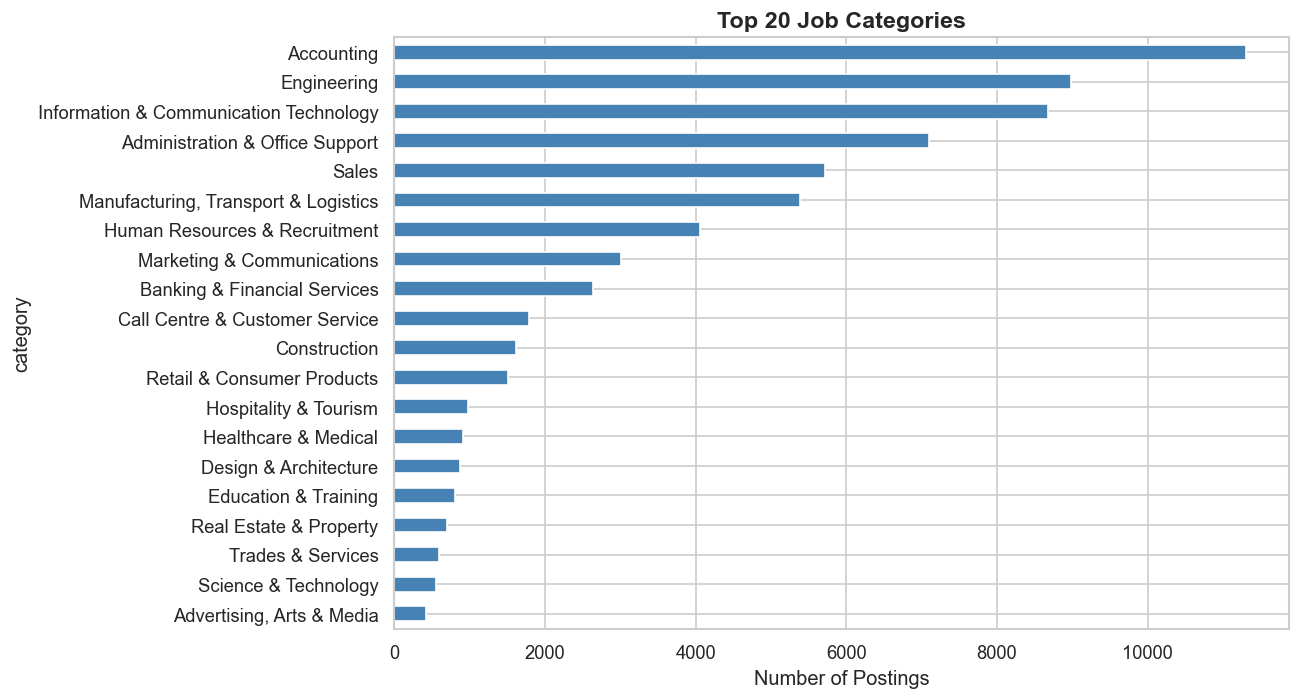

Unique categories: 30


In [16]:
if JOB_CAT_COL and JOB_CAT_COL in jobs_df.columns:
    top_cats = jobs_df[JOB_CAT_COL].value_counts().head(20)
    plt.figure(figsize=(11, 6))
    top_cats.plot(kind='barh', color='steelblue')
    plt.title('Top 20 Job Categories', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Postings')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f'Unique categories: {jobs_df[JOB_CAT_COL].nunique()}')

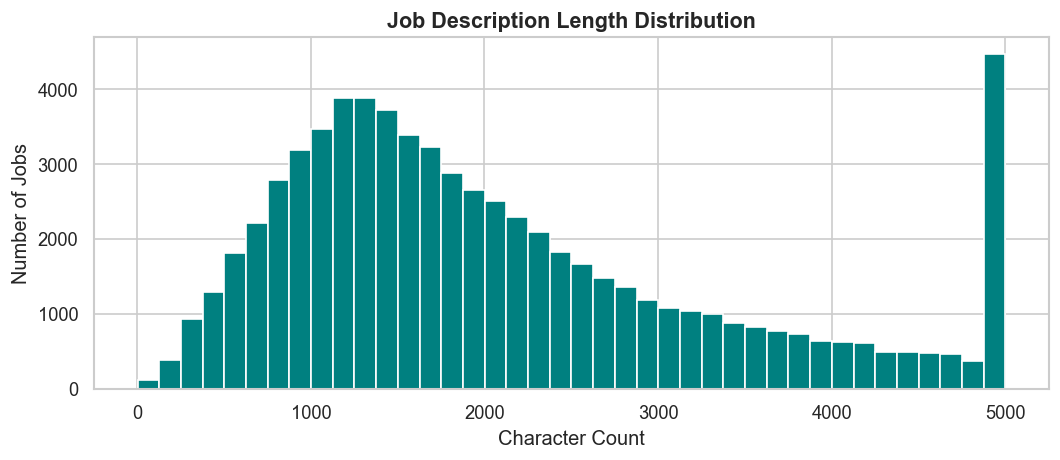

Avg length: 2190 | Min: 2 | Max: 16256


In [17]:
if JOB_DESC_COL:
    desc_len = jobs_df[JOB_DESC_COL].astype(str).str.len()
    plt.figure(figsize=(9, 4))
    desc_len.clip(upper=5000).hist(bins=40, color='teal', edgecolor='white')
    plt.title('Job Description Length Distribution', fontsize=13, fontweight='bold')
    plt.xlabel('Character Count')
    plt.ylabel('Number of Jobs')
    plt.tight_layout()
    plt.show()
    print(f'Avg length: {desc_len.mean():.0f} | Min: {desc_len.min()} | Max: {desc_len.max()}')

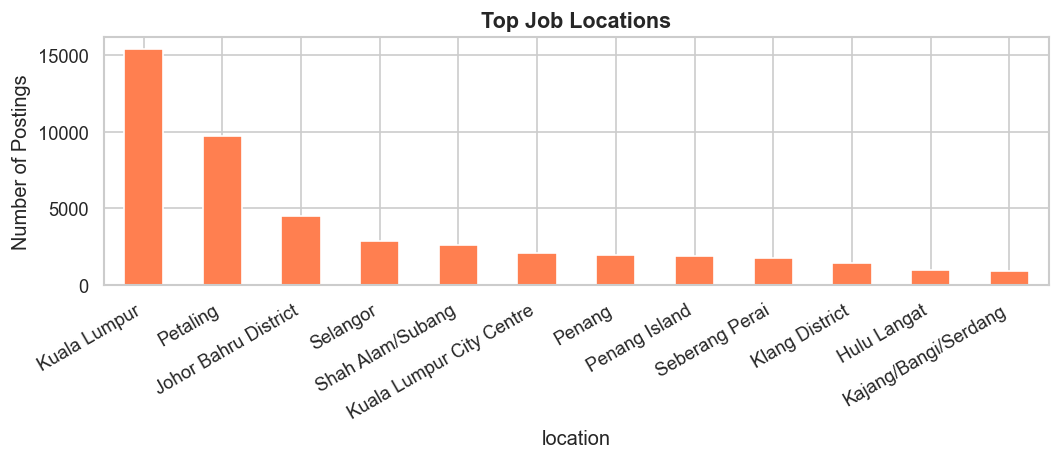

In [18]:
if JOB_LOC_COL and JOB_LOC_COL in jobs_df.columns:
    top_locs = jobs_df[JOB_LOC_COL].value_counts().head(12)
    plt.figure(figsize=(9, 4))
    top_locs.plot(kind='bar', color='coral')
    plt.title('Top Job Locations', fontsize=13, fontweight='bold')
    plt.ylabel('Number of Postings')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## Step 4: Preprocessing

In [20]:
print('Preprocessing...')
before = len(jobs_df)

req_cols = [c for c in [JOB_TITLE_COL, JOB_DESC_COL] if c]
jobs_df = jobs_df.dropna(subset=req_cols)
print(f'After dropping nulls      : {len(jobs_df):,} (removed {before - len(jobs_df)})')

for col in req_cols:
    jobs_df[col] = jobs_df[col].astype(str).apply(clean_text)

# Remove non-English descriptions (>30% non-ASCII = likely Chinese/other)
def is_mostly_english(text, threshold=0.70):
    if not text.strip(): return False
    return sum(1 for c in text if ord(c) < 128) / len(text) >= threshold

before = len(jobs_df)
jobs_df = jobs_df[jobs_df[JOB_DESC_COL].apply(is_mostly_english)].reset_index(drop=True)
print(f'After English-only filter : {len(jobs_df):,} (removed {before - len(jobs_df)})')

# Remove very short descriptions
before = len(jobs_df)
jobs_df = jobs_df[jobs_df[JOB_DESC_COL].str.len() >= 50].reset_index(drop=True)
print(f'After removing short      : {len(jobs_df):,} (removed {before - len(jobs_df)})')

# Deduplicate by job title + company
before = len(jobs_df)
dedup_cols = [c for c in [JOB_TITLE_COL, JOB_COMP_COL] if c and c in jobs_df.columns]
jobs_df = jobs_df.drop_duplicates(
    subset=dedup_cols if dedup_cols else req_cols, keep='first'
).reset_index(drop=True)
print(f'After deduplication       : {len(jobs_df):,} (removed {before - len(jobs_df)})')

job_texts = jobs_df[JOB_DESC_COL].tolist()
print(f'\nFinal dataset: {len(job_texts):,} jobs')

Preprocessing...
After dropping nulls      : 69,024 (removed 0)
After English-only filter : 68,834 (removed 190)
After removing short      : 68,790 (removed 44)
After deduplication       : 62,070 (removed 6720)

Final dataset: 62,070 jobs


## Step 5: Data Mining — Most In-Demand Skills

Counting skill mentions across all job postings...


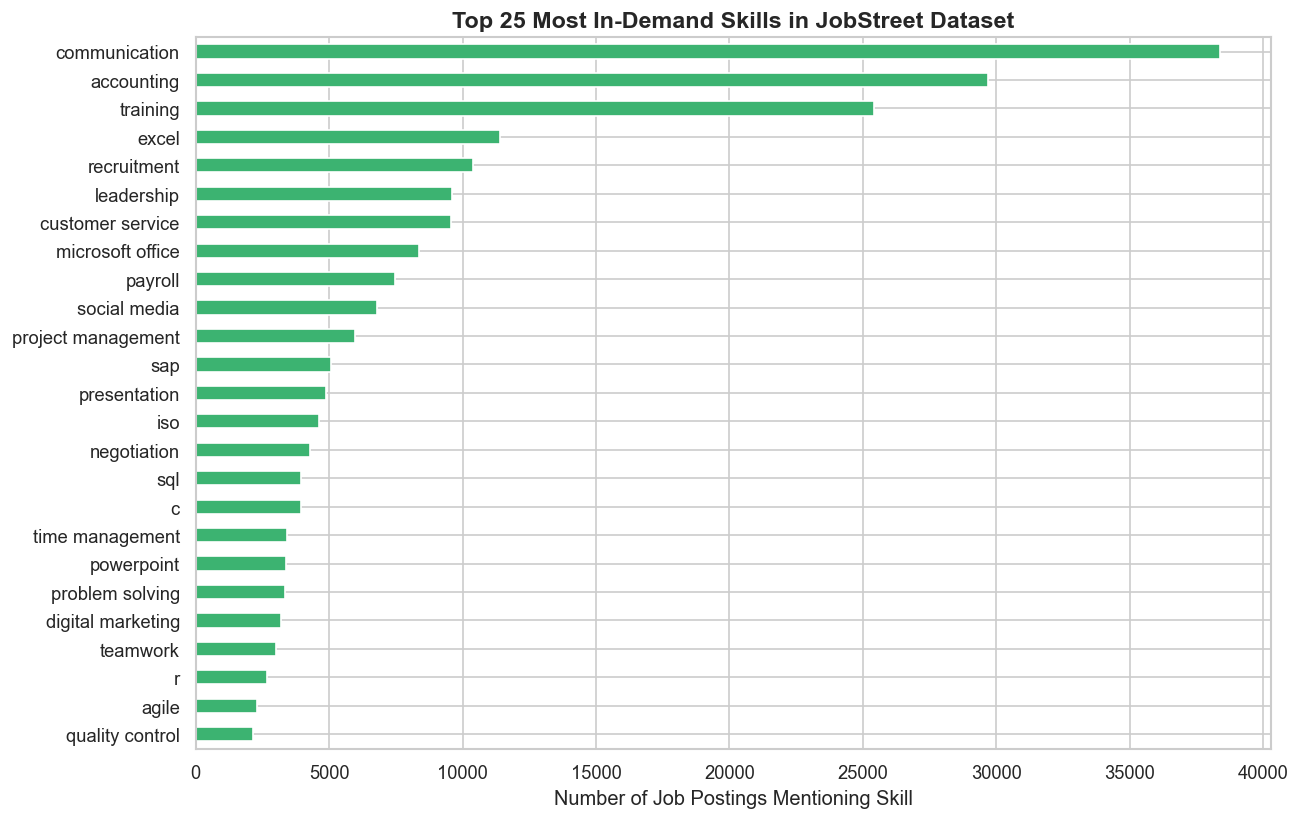

Top 15:
communication         38376
accounting            29696
training              25419
excel                 11409
recruitment           10387
leadership             9593
customer service       9570
microsoft office       8361
payroll                7467
social media           6794
project management     5951
sap                    5074
presentation           4894
iso                    4633
negotiation            4284


In [22]:
# Use the same SKILL_KEYWORDS that are used in skill gap analysis
# Count how many job postings mention each skill
SKILL_KEYWORDS = [
    'python','java','javascript','typescript','c++','c#','c','r','php','ruby',
    'go','swift','kotlin','scala','matlab','perl','bash','shell','vba',
    'html','css','react','angular','vue','jquery','bootstrap','node.js',
    'django','flask','fastapi','spring','express','.net','laravel',
    'machine learning','deep learning','nlp','natural language processing',
    'computer vision','data science','data analysis','data mining','statistics',
    'statistical analysis','feature engineering','etl',
    'pandas','numpy','scikit-learn','tensorflow','pytorch','keras','xgboost',
    'matplotlib','seaborn','plotly','opencv',
    'sql','mysql','postgresql','mongodb','redis','oracle','sqlite',
    'elasticsearch','nosql','ms sql','dynamodb',
    'aws','azure','gcp','docker','kubernetes','terraform','ansible',
    'jenkins','git','ci/cd','linux','unix','airflow','kafka','spark',
    'hadoop','databricks','snowflake',
    'tableau','power bi','excel','sas','spss','google analytics',
    'microsoft office','powerpoint',
    'agile','scrum','jira','project management','devops','uml',
    'accounting','bookkeeping','auditing','taxation','financial reporting',
    'financial analysis','budgeting','forecasting','sap','quickbooks','xero',
    'digital marketing','seo','sem','social media','content marketing',
    'email marketing','google ads','crm','salesforce','market research',
    'recruitment','payroll','hris','training','performance management',
    'autocad','solidworks','electrical engineering','mechanical engineering',
    'civil engineering','quality control','iso',
    'patient care','clinical','nursing','pharmacy','laboratory',
    'communication','presentation','leadership','teamwork','negotiation',
    'customer service','problem solving','time management'
]

print('Counting skill mentions across all job postings...')
corpus = ' '.join(jobs_df[JOB_DESC_COL].astype(str).str.lower().tolist())
skill_counts = {}
for sk in SKILL_KEYWORDS:
    count = len(re.findall(r'\b' + re.escape(sk) + r'\b', corpus))
    if count > 0:
        skill_counts[sk] = count

skill_demand = pd.Series(skill_counts).sort_values(ascending=False)

plt.figure(figsize=(11, 7))
skill_demand.head(25).plot(kind='barh', color='mediumseagreen')
plt.title('Top 25 Most In-Demand Skills in JobStreet Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('Top 15:')
print(skill_demand.head(15).to_string())

## Step 6: Load SBERT Model

In [24]:
SBERT_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
print(f'Loading: {SBERT_NAME}')
sbert_model = SentenceTransformer(SBERT_NAME)
print('Model ready.')

Loading: sentence-transformers/all-MiniLM-L6-v2
Model ready.


## Step 7: Precompute and Save All Scores

Runs once. Saves TF-IDF scores, SBERT embeddings, SBERT scores, and Hybrid scores for every job to disk. Future runs load from disk instantly.

In [26]:
os.makedirs('data', exist_ok=True)

TFIDF_VEC_PATH    = 'data/job_tfidf_vec.pkl'
TFIDF_MAT_PATH    = 'data/job_tfidf_matrix.npz'
SBERT_EMB_PATH    = 'data/job_embs.npy'
JOB_DATA_PATH     = 'data/jobstreet_cleaned.csv'
JOB_META_PATH     = 'data/job_index_meta.pkl'

ALPHA = 0.3  # 30% SBERT, 70% TF-IDF
N = len(job_texts)

# Save the cleaned JobStreet data used by the app
jobs_df.to_csv(JOB_DATA_PATH, index=False)
print(f'Saved: {JOB_DATA_PATH}')

def job_index_ready():
    files = [TFIDF_VEC_PATH, TFIDF_MAT_PATH, SBERT_EMB_PATH, JOB_META_PATH]
    if not all(os.path.exists(p) for p in files):
        return False
    try:
        with open(JOB_META_PATH, 'rb') as f:
            meta = pickle.load(f)
        return meta.get('n_jobs') == N and meta.get('model_name') == SBERT_NAME
    except Exception:
        return False

if job_index_ready():
    print('Loading saved JobStreet indexes...')
    with open(TFIDF_VEC_PATH, 'rb') as f:
        tfidf_vec = pickle.load(f)
    jobs_tfidf = load_npz(TFIDF_MAT_PATH)
    job_embs = np.load(SBERT_EMB_PATH)
else:
    print('Building JobStreet TF-IDF index...')
    tfidf_vec = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=15000)
    jobs_tfidf = tfidf_vec.fit_transform(job_texts)
    with open(TFIDF_VEC_PATH, 'wb') as f:
        pickle.dump(tfidf_vec, f)
    save_npz(TFIDF_MAT_PATH, jobs_tfidf)
    print(f'Saved: {TFIDF_VEC_PATH}')
    print(f'Saved: {TFIDF_MAT_PATH}')

    print('Building JobStreet SBERT embeddings...')
    job_embs = sbert_model.encode(
        job_texts,
        batch_size=64,
        normalize_embeddings=True,
        show_progress_bar=True
    )
    np.save(SBERT_EMB_PATH, job_embs)
    print(f'Saved: {SBERT_EMB_PATH}')

    with open(JOB_META_PATH, 'wb') as f:
        pickle.dump({
            'n_jobs': N,
            'model_name': SBERT_NAME,
            'alpha': ALPHA,
            'title_col': JOB_TITLE_COL,
            'desc_col': JOB_DESC_COL,
            'cat_col': JOB_CAT_COL,
            'company_col': JOB_COMP_COL,
            'location_col': JOB_LOC_COL
        }, f)
    print(f'Saved: {JOB_META_PATH}')

# Scores below are for this notebook test resume only
resume_tfidf = tfidf_vec.transform([resume_skills_text])
tfidf_scores = cosine_similarity(resume_tfidf, jobs_tfidf).flatten()

resume_emb = sbert_model.encode([resume_skills_text], normalize_embeddings=True)
sbert_scores = (job_embs @ resume_emb.T).flatten()

hybrid_scores = (1 - ALPHA) * tfidf_scores + ALPHA * sbert_scores

np.save('data/last_tfidf_scores.npy', tfidf_scores)
np.save('data/last_sbert_scores.npy', sbert_scores)
np.save('data/last_hybrid_scores.npy', hybrid_scores)
print('Saved last test-resume scores for notebook review.')

Saved: data/jobstreet_cleaned.csv
Loading saved JobStreet indexes...
Saved last test-resume scores for notebook review.


## Step 8: Load Scores and Retrieve Top 10 Jobs

In [28]:
DATA_DIR = "data"

TFIDF_SCORES_PATH = os.path.join(DATA_DIR, "last_tfidf_scores.npy")
SBERT_SCORES_PATH = os.path.join(DATA_DIR, "last_sbert_scores.npy")
HYBRID_SCORES_PATH = os.path.join(DATA_DIR, "last_hybrid_scores.npy")

tfidf_scores = np.load(TFIDF_SCORES_PATH)
sbert_scores = np.load(SBERT_SCORES_PATH)
hybrid_scores = np.load(HYBRID_SCORES_PATH)

TOP_K = 10
top_idx = np.argsort(-hybrid_scores)[:TOP_K]

top_jobs_df = jobs_df.iloc[top_idx].copy().reset_index(drop=True)
top_jobs_df["tfidf_score"] = tfidf_scores[top_idx]
top_jobs_df["sbert_score"] = sbert_scores[top_idx]
top_jobs_df["hybrid_score"] = hybrid_scores[top_idx]

show_cols = [c for c in [
    JOB_TITLE_COL, JOB_CAT_COL, JOB_COMP_COL,
    "tfidf_score", "sbert_score", "hybrid_score"
] if c and c in top_jobs_df.columns]

print(f"Top {TOP_K} jobs by Hybrid Score (0.7 TF-IDF + 0.3 SBERT):\n")
print(top_jobs_df[show_cols].to_string(index=False))

Top 10 jobs by Hybrid Score (0.7 TF-IDF + 0.3 SBERT):

                                                                   job_title                               category                                       company  tfidf_score  sbert_score  hybrid_score
        Developer (Vue.JS / PHP, React Native & HTML/CSS & SQL) (ID: 610843) Information & Communication Technology Agensi Pekerjaan PERSOLKELLY Malaysia Sdn Bhd     0.167289     0.502785      0.267938
                                                          Analyst Programmer Information & Communication Technology                                 Zanko Sdn Bhd     0.189630     0.399953      0.252727
                                                        Junior PHP Developer Information & Communication Technology                         Zen Digital Marketing     0.195503     0.384226      0.252120
                                                    Junior PHP Web Developer Information & Communication Technology                      

## Step 9: Skill Gap Analysis

In [30]:
def extract_skills_from_jd(job_desc):
    """Match known skill keywords against job description text."""
    desc_lower = job_desc.lower()
    # Skip non-English descriptions
    if len(desc_lower) > 0:
        ascii_ratio = sum(1 for c in desc_lower if ord(c) < 128) / len(desc_lower)
        if ascii_ratio < 0.70:
            return set()
    found = set()
    for sk in SKILL_KEYWORDS:
        if re.search(r'\b' + re.escape(sk) + r'\b', desc_lower):
            found.add(sk)
    return found


def compute_skill_gap(user_skills_set, job_desc):
    """Compare user skills against job required skills."""
    required = extract_skills_from_jd(job_desc)
    if not required:
        return {'required':[],'matched':[],'missing':[],'match_pct':0.0,'gap_score':1.0}

    user_lower = set(s.lower() for s in user_skills_set)
    matched, missing = set(), set()
    for req in required:
        hit = req in user_lower or any(req in u or u in req for u in user_lower)
        (matched if hit else missing).add(req)

    match_pct = len(matched) / len(required) * 100
    return {
        'required': sorted(required),
        'matched':  sorted(matched),
        'missing':  sorted(missing),
        'match_pct': round(match_pct, 2),
        'gap_score': round(1 - match_pct / 100, 3)
    }


print('Computing skill gaps...\n')
gap_results = []
for i, row in top_jobs_df.iterrows():
    gap = compute_skill_gap(resume_skills_set, row.get(JOB_DESC_COL, ''))
    gap_results.append({
        'rank':            i + 1,
        'job_title':       row.get(JOB_TITLE_COL, f'Job {i+1}'),
        'category':        row.get(JOB_CAT_COL, 'N/A') if JOB_CAT_COL else 'N/A',
        'company':         row.get(JOB_COMP_COL, 'N/A') if JOB_COMP_COL else 'N/A',
        'hybrid_score':    round(float(row['hybrid_score']), 4),
        'tfidf_score':     round(float(row['tfidf_score']), 4),
        'sbert_score':     round(float(row['sbert_score']), 4),
        'match_pct':       gap['match_pct'],
        'gap_score':       gap['gap_score'],
        'matched_skills':  gap['matched'],
        'missing_skills':  gap['missing'],
        'required_skills': gap['required']
    })

gap_df = pd.DataFrame(gap_results)
print(gap_df[['rank','job_title','category','hybrid_score','match_pct','gap_score']].to_string(index=False))

Computing skill gaps...

 rank                                                                    job_title                               category  hybrid_score  match_pct  gap_score
    1         Developer (Vue.JS / PHP, React Native & HTML/CSS & SQL) (ID: 610843) Information & Communication Technology        0.2679      63.64      0.364
    2                                                           Analyst Programmer Information & Communication Technology        0.2527      35.29      0.647
    3                                                         Junior PHP Developer Information & Communication Technology        0.2521      57.14      0.429
    4                                                     Junior PHP Web Developer Information & Communication Technology        0.2491      57.14      0.429
    5                                                  Java Programmer (Executive) Information & Communication Technology        0.2469      85.71      0.143
    6 System Developer (Rea

In [31]:
print('\nDetailed Skill Gap Per Job:')
print('=' * 60)
for _, row in gap_df.iterrows():
    print(f"\nRank {row['rank']}: {row['job_title']}")
    print(f"  Company      : {row['company']}")
    print(f"  Category     : {row['category']}")
    print(f"  Hybrid Score : {row['hybrid_score']:.4f}  "
          f"(TF-IDF: {row['tfidf_score']:.4f}, SBERT: {row['sbert_score']:.4f})")
    print(f"  Match %      : {row['match_pct']:.1f}%  |  Gap Score: {row['gap_score']:.3f}")
    print(f"  Required ({len(row['required_skills'])}): "
          f"{', '.join(row['required_skills']) if row['required_skills'] else 'None detected'}")
    print(f"  Matched  ({len(row['matched_skills'])}): "
          f"{', '.join(row['matched_skills']) if row['matched_skills'] else 'None'}")
    print(f"  Missing  ({len(row['missing_skills'])}): "
          f"{', '.join(row['missing_skills']) if row['missing_skills'] else 'No gap — perfect match!'}")


Detailed Skill Gap Per Job:

Rank 1: Developer (Vue.JS / PHP, React Native & HTML/CSS & SQL) (ID: 610843)
  Company      : Agensi Pekerjaan PERSOLKELLY Malaysia Sdn Bhd
  Category     : Information & Communication Technology
  Hybrid Score : 0.2679  (TF-IDF: 0.1673, SBERT: 0.5028)
  Match %      : 63.6%  |  Gap Score: 0.364
  Required (11): css, html, javascript, laravel, ms sql, mysql, php, python, react, sql, vue
  Matched  (7): css, html, javascript, ms sql, mysql, python, sql
  Missing  (4): laravel, php, react, vue

Rank 2: Analyst Programmer
  Company      : Zanko Sdn Bhd
  Category     : Information & Communication Technology
  Hybrid Score : 0.2527  (TF-IDF: 0.1896, SBERT: 0.4000)
  Match %      : 35.3%  |  Gap Score: 0.647
  Required (17): agile, aws, azure, c, communication, css, data mining, html, java, javascript, jquery, laravel, leadership, linux, php, presentation, python
  Matched  (6): c, css, html, java, javascript, python
  Missing  (11): agile, aws, azure, communic

## Step 10: Visualise Skill Gap

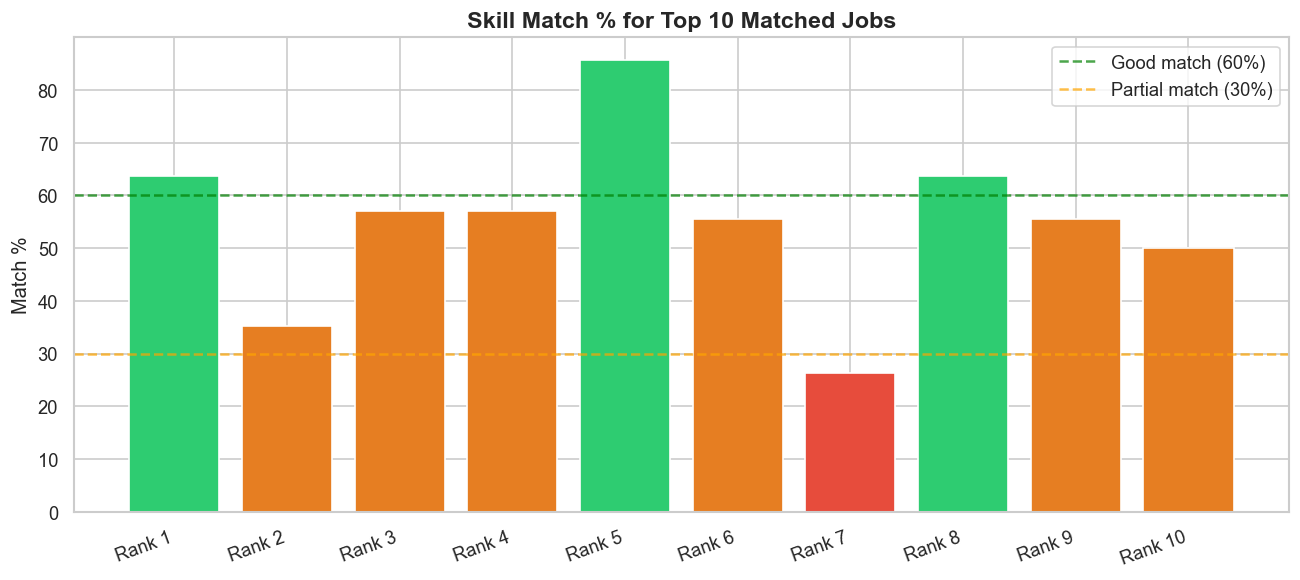

In [33]:
colors = ['#2ecc71' if p >= 60 else '#e67e22' if p >= 30 else '#e74c3c'
          for p in gap_df['match_pct']]
plt.figure(figsize=(11, 5))
plt.bar([f"Rank {r}" for r in gap_df['rank']], gap_df['match_pct'], color=colors)
plt.axhline(60, color='green', linestyle='--', alpha=0.7, label='Good match (60%)')
plt.axhline(30, color='orange', linestyle='--', alpha=0.7, label='Partial match (30%)')
plt.title('Skill Match % for Top 10 Matched Jobs', fontsize=14, fontweight='bold')
plt.ylabel('Match %')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

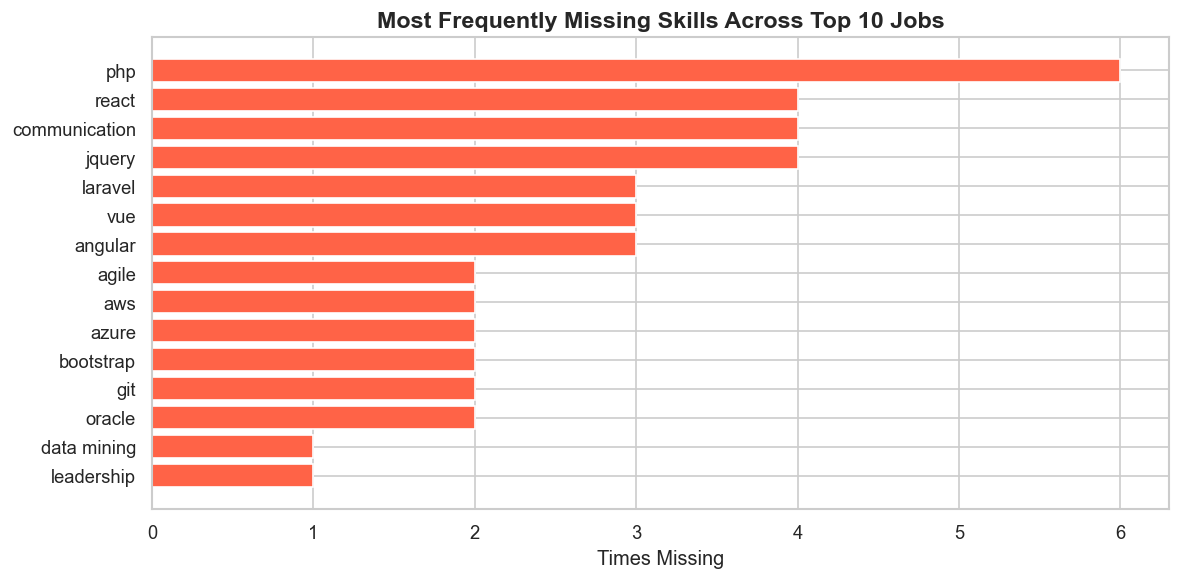

In [34]:
all_missing = []
for _, row in gap_df.iterrows():
    all_missing.extend(row['missing_skills'])

missing_counts = Counter(all_missing)
if missing_counts:
    mc_df = pd.DataFrame(missing_counts.most_common(15), columns=['Skill','Count'])
    plt.figure(figsize=(10, 5))
    plt.barh(mc_df['Skill'], mc_df['Count'], color='tomato')
    plt.title('Most Frequently Missing Skills Across Top 10 Jobs', fontsize=14, fontweight='bold')
    plt.xlabel('Times Missing')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('No missing skills detected.')

## Step 11: Save Outputs

In [36]:
os.makedirs('data', exist_ok=True)

gap_df.to_csv('data/skill_gap_results.csv', index=False)
print('Saved: data/skill_gap_results.csv')

user_profile = {
    'skills':           resume_skills,
    'education':        resume_education,
    'roles':            resume_roles,
    'years_experience': years_exp
}
with open('data/user_profile.json', 'w') as f:
    json.dump(user_profile, f, indent=2)
print('Saved: data/user_profile.json')

gap_df.head()

Saved: data/skill_gap_results.csv
Saved: data/user_profile.json


,rank,job_title,category,company,hybrid_score,tfidf_score,sbert_score,match_pct,gap_score,matched_skills,missing_skills,required_skills
0,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",Information & Communication Technology,Agensi Pekerjaan PERSOLKELLY Malaysia Sdn Bhd,0.2679,0.1673,0.5028,63.64,0.364,"[css, html, javascript, ms sql, mysql, python,...","[laravel, php, react, vue]","[css, html, javascript, laravel, ms sql, mysql..."
1,2,Analyst Programmer,Information & Communication Technology,Zanko Sdn Bhd,0.2527,0.1896,0.4000,35.29,0.647,"[c, css, html, java, javascript, python]","[agile, aws, azure, communication, data mining...","[agile, aws, azure, c, communication, css, dat..."
2,3,Junior PHP Developer,Information & Communication Technology,Zen Digital Marketing,0.2521,0.1955,0.3842,57.14,0.429,"[css, html, javascript, mysql]","[bootstrap, communication, php]","[bootstrap, communication, css, html, javascri..."
3,4,Junior PHP Web Developer,Information & Communication Technology,Zen Digital Marketing,0.2491,0.1912,0.3842,57.14,0.429,"[css, html, javascript, mysql]","[bootstrap, communication, php]","[bootstrap, communication, css, html, javascri..."
4,5,Java Programmer (Executive),Information & Communication Technology,LONPAC INSURANCE BHD 199401021735 (307414-T),0.2469,0.1627,0.4433,85.71,0.143,"[css, html, java, javascript, ms sql, sql]",[angular],"[angular, css, html, java, javascript, ms sql,..."


In [37]:
# Save reusable JobStreet indexes for Streamlit
import os
import pickle
import pandas as pd
import numpy as np
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

job_paths = [
    os.path.join(DATA_DIR, 'jobstreet_cleaned.csv'),
    os.path.join(DATA_DIR, 'jobstreet_all_job_dataset.csv'),
    'jobstreet_cleaned.csv',
    'jobstreet_all_job_dataset.csv'
]
job_path = next((p for p in job_paths if os.path.exists(p)), None)
if job_path is None:
    raise FileNotFoundError('JobStreet dataset not found.')

jobs_df = pd.read_csv(job_path)

def detect_col(df, names):
    for name in names:
        if name in df.columns:
            return name
    return None

JOB_TITLE_COL = detect_col(jobs_df, ['job_title', 'Job Title', 'title', 'position'])
JOB_DESC_COL = detect_col(jobs_df, ['job_description', 'descriptions', 'description', 'desc', 'requirements'])
JOB_CAT_COL = detect_col(jobs_df, ['category', 'Category', 'field', 'industry', 'job_category', 'specialization'])
JOB_COMP_COL = detect_col(jobs_df, ['company', 'Company', 'company_name', 'employer'])
JOB_LOC_COL = detect_col(jobs_df, ['location', 'Location', 'city', 'state'])

if JOB_DESC_COL is None:
    raise ValueError('Job description column not found.')

for col in [JOB_TITLE_COL, JOB_DESC_COL, JOB_CAT_COL, JOB_COMP_COL, JOB_LOC_COL]:
    if col and col in jobs_df.columns:
        jobs_df[col] = jobs_df[col].fillna('').astype(str)

jobs_df = jobs_df[jobs_df[JOB_DESC_COL].str.len() > 20].copy()
jobs_df = jobs_df.drop_duplicates(subset=[c for c in [JOB_TITLE_COL, JOB_DESC_COL, JOB_COMP_COL] if c]).reset_index(drop=True)
jobs_df['job_text'] = (
    jobs_df[JOB_TITLE_COL].fillna('') + ' ' +
    jobs_df[JOB_DESC_COL].fillna('') + ' ' +
    (jobs_df[JOB_CAT_COL].fillna('') if JOB_CAT_COL else '')
)

jobs_df.to_csv(os.path.join(DATA_DIR, 'jobstreet_cleaned.csv'), index=False)

job_tfidf_vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=30000)
job_tfidf_matrix = job_tfidf_vec.fit_transform(jobs_df['job_text'])

with open(os.path.join(DATA_DIR, 'job_tfidf_vec.pkl'), 'wb') as f:
    pickle.dump(job_tfidf_vec, f)
save_npz(os.path.join(DATA_DIR, 'job_tfidf_matrix.npz'), job_tfidf_matrix)

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
job_embs = model.encode(
    jobs_df['job_text'].tolist(),
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)
np.save(os.path.join(DATA_DIR, 'job_embs.npy'), job_embs)

meta = {
    'n_jobs': len(jobs_df),
    'title_col': JOB_TITLE_COL,
    'desc_col': JOB_DESC_COL,
    'category_col': JOB_CAT_COL,
    'company_col': JOB_COMP_COL,
    'location_col': JOB_LOC_COL,
    'model_name': 'sentence-transformers/all-MiniLM-L6-v2'
}
with open(os.path.join(DATA_DIR, 'job_index_meta.pkl'), 'wb') as f:
    pickle.dump(meta, f)

print('Saved JobStreet indexes.')
print('Jobs:', len(jobs_df))
print('TF-IDF matrix:', job_tfidf_matrix.shape)
print('SBERT embeddings:', job_embs.shape)

Batches:   0%|          | 0/970 [00:00<?, ?it/s]

Saved JobStreet indexes.
Jobs: 62070
TF-IDF matrix: (62070, 30000)
SBERT embeddings: (62070, 384)
